In [1]:
from pathlib import Path
from typing import List, Dict
import pandas as pd
from matplotlib import pyplot as plt
import statistics as st
import statsmodels.api as sm
import numpy as np
import random as rd
import os
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## Graph of making comparison between Experimental CV and Simulated CV for the 7 signals

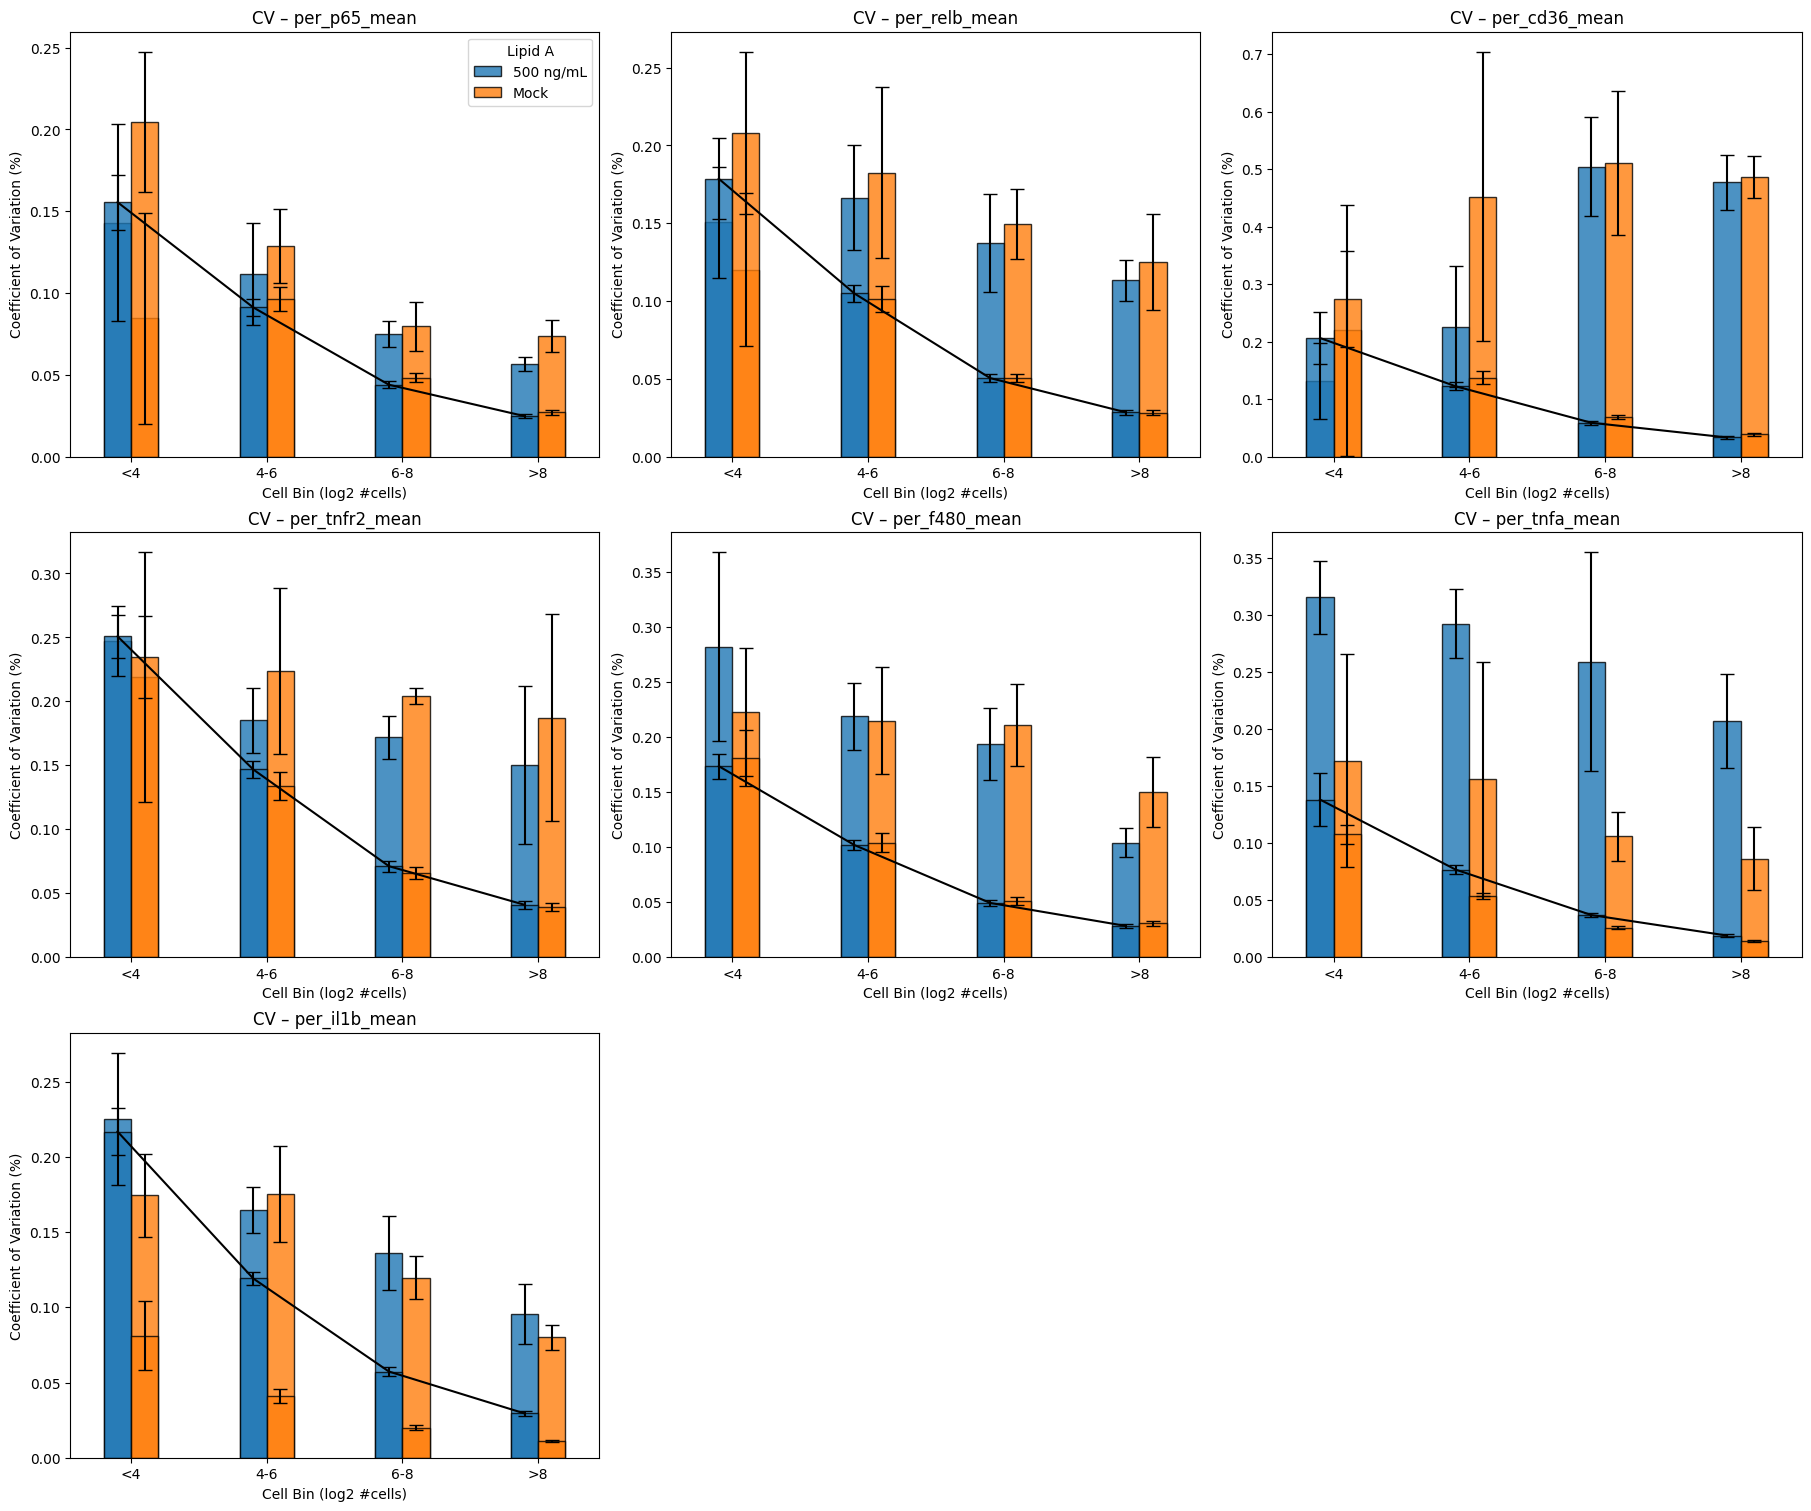

In [5]:
#!/usr/bin/env python
"""
Plot coefficient-of-variation data and save the figure as a true-vector SVG.

• Reads two CSV files, merges them, orders the “Cell_Bin” factor.
• Draws bars (experiment vs. theory) for each signal.
• Accepts either a grid of subplots or one plot per figure.
• ALWAYS writes the figure to SVG (set `svg_path`).
"""

# ------------------------------------------------------------------
# IMPORTS
# ------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.container import BarContainer
from math import ceil

# ------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------
CSV_P65_RELB_CD36 = "cv_experiment_vs_theory_p65_relb_cd36.csv"
CSV_TNFR2_F480    = "cv_experiment_vs_theory_tnfr2_f480.csv"
#CSV_TNFA_IL1B     = "cv_experiment_vs_theory_tnfa_il1b_if24.csv"
CSV_TNFA_IL1B     = "cv_experiment_vs_theory_tnfa_il1b_combine.csv"

SVG_PATH_GRID   = "cv_grid.svg"    # output when layout="grid"
SVG_PATH_SINGLE = "cv_single.svg"  # output when layout="single"

DEFAULT_SIGNALS = [
    "per_p65_mean", "per_relb_mean", "per_cd36_mean",
    "per_tnfr2_mean", "per_f480_mean","per_tnfa_mean","per_il1b_mean"
]

# ------------------------------------------------------------------
# LOAD & PREP DATA
# ------------------------------------------------------------------
def load_cv_data() -> pd.DataFrame:
    """Read, concatenate, and tidy the CV data."""
    p65_relb_cd36 = pd.read_csv(CSV_P65_RELB_CD36)
    tnfr2_f480    = pd.read_csv(CSV_TNFR2_F480)
    tnfa_il1b     = pd.read_csv(CSV_TNFA_IL1B)
    tidy_all      = pd.concat([p65_relb_cd36, tnfr2_f480,tnfa_il1b], ignore_index=True)

    cell_bin_order = ["<4", "4-6", "6-8", ">8"]
    tidy_all["Cell_Bin"] = pd.Categorical(
        tidy_all["Cell_Bin"],
        categories=cell_bin_order,
        ordered=True
    )
    return tidy_all

# ------------------------------------------------------------------
# PLOTTER
# ------------------------------------------------------------------
def plot_cv(
    tidy_all: pd.DataFrame,
    signals: list[str] | None = None,
    layout: str = "grid",
    ncols: int = 3,
    svg_path: str | None = None,
) -> None:
    """
    Draw coefficient-of-variation bars (experiment vs. theory).

    Parameters
    ----------
    tidy_all : DataFrame
    signals  : list[str]   – which signals to plot (default = all)
    layout   : "grid" | "single"
    ncols    : columns in the grid layout
    svg_path : str | None  – where to write the SVG (None = don’t save)
    """
    if signals is None:
        signals = DEFAULT_SIGNALS

    if layout not in {"grid", "single"}:
        raise ValueError("layout must be 'grid' or 'single'")

    # ---------- create axes ---------------------------------------
    if layout == "grid":
        nrows = ceil(len(signals) / ncols)
        fig, axes = plt.subplots(
            nrows=nrows,
            ncols=ncols,
            figsize=(6 * ncols, 5 * nrows),
            constrained_layout=True,
        )
        axes = axes.flatten()

    # ---------- loop over signals ---------------------------------
    for idx, sig in enumerate(signals):
        ax = (
            axes[idx] if layout == "grid"
            else plt.subplots(figsize=(8, 5))[1]
        )

        df_sig = tidy_all[tidy_all["Signal"] == sig]

        def pivot(src: str, val: str) -> pd.DataFrame:
            return (
                df_sig[df_sig["Source"] == src]
                .pivot(index="Cell_Bin", columns="Lipid A", values=val)
                .sort_index()
            )

        df_exp_mean = pivot("Experiment", "Mean")
        df_exp_sd   = pivot("Experiment", "SD")
        df_the_mean = pivot("Theory",     "Mean")
        df_the_sd   = pivot("Theory",     "SD")

        # ---- experiment bars ----
        df_exp_mean.plot(
            kind="bar",
            yerr=df_exp_sd,
            ax=ax,
            width=0.40,
            capsize=5,
            edgecolor="black",
            alpha=0.8,
            legend=False,
        )

        # ---- theory bars ----
        df_the_mean.plot(
            kind="bar",
            yerr=df_the_sd,
            ax=ax,
            width=0.40,
            capsize=5,
            edgecolor="black",
            alpha=0.8,
            legend=False,
        )

        # ---- centre-aligned theory line (stimulated only) ---------
        n_exp_cols = len(df_exp_mean.columns)
        theory_bars = [
            c for c in ax.containers[n_exp_cols:]
            if isinstance(c, BarContainer)
        ]
        for cont in theory_bars[1:2]:
            xc = [r.get_x() + r.get_width() / 2 for r in cont]
            yh = [r.get_height() for r in cont]
            ax.plot(xc, yh, linestyle="-", color="black",
                    marker="", label="_nolegend_")

        # ---- cosmetics -------------------------------------------
        ax.set_title(f"CV – {sig}")
        ax.set_xlabel("Cell Bin (log2 #cells)")
        ax.set_ylabel("Coefficient of Variation (%)")
        ax.set_xticklabels(df_exp_mean.index, rotation=0)

        # Legend only on first subplot / first single
        if idx == 0:
            h, l = ax.get_legend_handles_labels()
            ax.legend(h[:len(df_exp_mean.columns)],
                      l[:len(df_exp_mean.columns)],
                      title="Lipid A")
        else:
            if ax.get_legend():
                ax.get_legend().remove()

        if layout == "single":
            if svg_path:              # save each single plot separately
                single_svg = svg_path.replace(".svg", f"_{sig}.svg")
                ax.figure.savefig(single_svg, format="svg",
                                  bbox_inches="tight")
            plt.show()

    # ---- final touches for grid ---------------------------------
    if layout == "grid":
        # hide unused axes
        if len(signals) < len(axes):
            for ax in axes[len(signals):]:
                ax.axis("off")

        if svg_path:                  # write one combined SVG
            fig.savefig(svg_path, format="svg", bbox_inches="tight")
        plt.show()


# ------------------------------------------------------------------
# MAIN
# ------------------------------------------------------------------
if __name__ == "__main__":
    # 1. Load & tidy data
    tidy = load_cv_data()

    # 2. Plot all signals in a single grid and save as vector
    plot_cv(
        tidy_all=tidy,
        layout="grid",
        ncols=3,
        svg_path=SVG_PATH_GRID,
    )

    # 3. (Optional) one-plot-per-figure version
    # plot_cv(
    #     tidy_all=tidy,
    #     layout="single",
    #     svg_path=SVG_PATH_SINGLE,
    # )
